# CSC-52081-EP Lab3: Dynamic Programming - Value Iteration and Policy Iteration

<img src="https://raw.githubusercontent.com/jeremiedecock/polytechnique-csc-52081-ep-2026-students/refs/heads/main/assets/logo.jpg" style="float: left; width: 15%" />

[CSC-52081-EP-2026](https://moodle.ip-paris.fr/course/view.php?id=10691) Lab session #3

2019-2026 Jérémie Decock

[![Open in Google Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jeremiedecock/polytechnique-csc-52081-ep-2026-students/blob/main/lab3_rl1_dynamic_programming.ipynb)

[![My Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/jeremiedecock/polytechnique-csc-52081-ep-2026-students/main?filepath=lab3_rl1_dynamic_programming.ipynb)

[![NbViewer](https://raw.githubusercontent.com/jupyter/design/main/logos/Badges/nbviewer_badge.svg)](https://nbviewer.jupyter.org/github/jeremiedecock/polytechnique-csc-52081-ep-2026-students/blob/main/lab3_rl1_dynamic_programming.ipynb)

[![Local](https://img.shields.io/badge/Local-Save%20As...-blue)](https://github.com/jeremiedecock/polytechnique-csc-52081-ep-2026-students/raw/main/lab3_rl1_dynamic_programming.ipynb)

## Introduction

The purpose of this lab is to introduce some classic concepts used
in reinforcement learning like *Dynamic Programming*, *Bellman's Principle of Optimality* and *Bellman equations*.

You will implement and test the two main dynamic programming algorithms (*Value Iteration* and *Policy Iteration*) in this Python notebook.

You can either:
- open, edit and execute the notebook in *Google Colab* following this link: https://colab.research.google.com/github/jeremiedecock/polytechnique-csc-52081-ep-2026-students/blob/main/lab3_rl1_dynamic_programming.ipynb ; this is the **recommended** choice as you have nothing to install on your computer
- open, edit and execute the notebook in *MyBinder* (if for any reason the Google Colab solution doesn't work): https://mybinder.org/v2/gh/jeremiedecock/polytechnique-csc-52081-ep-2026-students/main?filepath=lab3_rl1_dynamic_programming.ipynb
- download, edit and execute the notebook on your computer if Python3 and JupyterLab are already installed: https://github.com/jeremiedecock/polytechnique-csc-52081-ep-2026-students/raw/main/lab3_rl1_dynamic_programming.ipynb

If you work with Google Colab or MyBinder, **remember to save or download your work regularly or you may lose it!**

### Survey

To begin with, please answer the following survey to help us improve this lab session: https://moodle.ip-paris.fr/mod/questionnaire/view.php?id=185070

## Lab Submission

Please submit your completed notebook in [Moodle : "Lab 3 - Submission"](https://moodle.ip-paris.fr/mod/assign/view.php?id=185074).

### Submission Guidelines

1. **File Naming:** Rename your notebook as follows: **`firstname_lastname-03.ipynb`** where `firstname` and `lastname` match your email address. *Example: `jesse_read-03.ipynb`*
2. **Clear Output Cells:** To reduce file size (**must be under 500 KB**), clear all output cells before submitting. This includes rendered images, videos, plots, and dataframes...
   - **JupyterLab:**
     - Click **"Kernel" → "Restart Kernel and Clear Outputs of All Cells..."**
     - Then go to **"File" → "Save Notebook As..."**
   - **Google Colab:**
     - Click **"Edit" → "Clear all outputs"**
     - Then go to **"File" → "Download" → "Download.ipynb"**
   - **VSCode:**
     - Click **"Clear All Outputs"**
     - Then **save your file**
3. **Upload Your File:** Only **`.ipynb`** files are accepted.

**Note:** Bonus parts (if any) are optional, as their name suggests.


## Setup the Python environment

This notebook relies on several libraries including `gymnasium[toy-text]` (v1.0.0), `ipywidgets`, `matplotlib`, `moviepy`, `numpy`, `pandas`, `pygame`, `seaborn`, and `tqdm`.
A complete list of dependencies can be found in the following [requirements-lab3.txt](https://raw.githubusercontent.com/jeremiedecock/polytechnique-csc-52081-ep-2026-students/main/requirements-lab3.txt) file.

### If you use Google Colab

If you use Google Colab, execute the next cell to install required libraries.

In [ ]:
import sys, subprocess

def is_colab():
    return "google.colab" in sys.modules

def run_subprocess_command(cmd):
    # run the command
    process = subprocess.Popen(cmd.split(), stdout=subprocess.PIPE)
    # print the output
    for line in process.stdout:
        print(line.decode().strip())

if is_colab():
    # run_subprocess_command("apt install xvfb x11-utils")
    run_subprocess_command("pip install -r https://raw.githubusercontent.com/jeremiedecock/polytechnique-csc-52081-ep-2026-students/main/requirements-lab3-google-colab.txt")

### If you have downloaded the notebook on your computer and execute it in your own Python environment

To set up the necessary dependencies, run the following commands to establish a [Python virtual environment (venv)](https://docs.python.org/3/library/venv.html) that includes all the essential libraries for this lab.

#### On POSIX systems (Linux, MacOSX, WSL, ...)

```bash
python3 -m venv env-lab3
source env-lab3/bin/activate
python3 -m pip install --upgrade pip
python3 -m pip install -r https://raw.githubusercontent.com/jeremiedecock/polytechnique-csc-52081-ep-2026-students/main/requirements-lab3.txt
```

#### On Windows

```bash
python3 -m venv env-lab3
env-lab3\Scripts\activate.bat
python3 -m pip install --upgrade pip
python3 -m pip install -r https://raw.githubusercontent.com/jeremiedecock/polytechnique-csc-52081-ep-2026-students/main/requirements-lab3.txt
```

### Run CSC-52081-EP notebooks locally in a dedicated Docker container

If you are familiar with Docker, an image is available on Docker Hub for this lab:

```bash
docker run -it --rm --user root -p 8888:8888 -e NB_UID=$(id -u) -e NB_GID=$(id -g) -v "${PWD}":/home/jovyan/work jdhp/csc-52081-ep:latest
```

### Import required packages

In [1]:
import gymnasium as gym
import math
import numpy as np
import copy
import pandas as pd

from typing import Callable, cast, Dict, List, Optional, Tuple, Union

In [2]:
%matplotlib inline

import matplotlib.pyplot as plt

import seaborn as sns

In [3]:
from IPython.display import Video

In [4]:
sns.set_context("talk")

## Backward Induction

**Notice**: Here we assume that the reward only depends on the state: $r(\boldsymbol{s}) \equiv \mathcal{R}(\boldsymbol{s}, \boldsymbol{a}, \boldsymbol{s}')$.

*Backward Induction* is a basic *Dynamic Programming* method **[BELLMAN57]**.
Like other Dynamic Programming algorithms, it uses the *Bellman's
Principle of Optimality* **[BELLMAN57]** for accelerating computation (compared
to an exhaustive search). It can be applied to problems that exhibit a compatible structure, i.e., a problem that has *overlapping subproblems* and an *optimal substructure* **[BELLMAN57]**.
Actually, this acceleration is obtained by breaking problems down into simpler subproblems in such a manner
that redundant computations are avoided by storing results.
When applicable, the method takes far less time than naïve methods that don't take advantage of the subproblem overlap (like depth-first search).

*Backward Induction* computes **non-stationary** policies: a new policy is computed for each time step.
Thus the number of time steps used to solve the problem is set in advance.
*Backward Induction* algorithms solve Sequential Decision Making problems defined with
discrete actions and state spaces.

The *value* (or *utility*) $V^*$ for each state $\boldsymbol{s}$ at the latest time step $T$ is
$$
V^*_T(\boldsymbol{s}) = r(\boldsymbol{s})
$$
where $r$ is the immediate reward function.

The best expected value $V^*$ for each state $\boldsymbol{s}$ at the $t^{\text{th}}$ time step is
$$
V^*_t(\boldsymbol{s}) = r(\boldsymbol{s}) + \max_{\boldsymbol{a} \in \mathcal{A}} \left[ \sum_{\boldsymbol{s}' \in \mathcal{S}} P(\boldsymbol{s}' | \boldsymbol{s}, \boldsymbol{a}) V^*_{t+1}(\boldsymbol{s}') \right]  \tag{1}
$$
and the $t^{\text{th}}$ optimal action (or decision) $d^*_t(\boldsymbol{s})$ among the set of
possible actions $\mathcal{A}$ is
$$
d^*_t(\boldsymbol{s}) = \arg\max_{\boldsymbol{a} \in \mathcal{A}} \left[ \sum_{\boldsymbol{s}' \in \mathcal{S}} P(\boldsymbol{s}' | \boldsymbol{s}, \boldsymbol{a}) V^*_{t+1}(\boldsymbol{s}') \right]  \tag{2}
$$
where $P(\cdot \mid \boldsymbol{s},\boldsymbol{a})$ is the transition probability distribution over next states.

The main idea is to compute the expected value of each state
(Eq. 1) and then to use it to select the
best action for any given state (Eq. 2).

Eq. 1 cannot be solved analytically because
the system of equations to compute $V$ contains non-linear terms (due to the
"max" operator).
As an alternative, Eq. 1
is usually computed using Dynamic Programming method, as described in Algorithm 1.

___
### Algorithm 1: Backward Induction

**Input**:<br>
$\quad$ $mdp = \langle \mathcal{S}, \mathcal{A}, P, r \rangle$, a Markov Decision Process <br>
$\quad$ $T$, the resolution horizon (i.e. the number of time steps) <br>
**Local variables**: <br>
$\quad$ $V^*_t ~~ \forall t \in \{1, ..., T\}$, value array (expected global reward following the optimal policy for states in $\mathcal{S}$) <br>
<br>
$V^*_T[\boldsymbol{s}] \leftarrow r(\boldsymbol{s}) ~~ \forall \boldsymbol{s} \in \mathcal{S}$ <br>
**for all** $t \in \{T-1, T-2, ..., 1\}$ **do** <br>
$\quad$ **for all** $\boldsymbol{s} \in \mathcal{S}$ **do** <br>
$\quad\quad$ **if** $\boldsymbol{s}$ is a final state **then** <br>
$\quad\quad\quad$ $\displaystyle V^*_t[\boldsymbol{s}] \leftarrow r(\boldsymbol{s})$ <br>
$\quad\quad$ **else** <br>
$\quad\quad\quad$ $\displaystyle V^*_t[\boldsymbol{s}] \leftarrow r(\boldsymbol{s}) + \max_{\boldsymbol{a} \in \mathcal{A}} \left[ \sum_{\boldsymbol{s}' \in \mathcal{S}} P(\boldsymbol{s}' | \boldsymbol{s}, \boldsymbol{a}) V^*_{t+1}[\boldsymbol{s}'] \right]$ <br>
$\quad\quad$ **end if** <br>
$\quad$ **end for** <br>
**end for** <br>
<br>
**return** $V^*_t ~~ \forall t \in \{1, ..., T\}$
___

## Exercise 1: Value Iteration

*Value Iteration* **[BELLMAN57]** is one of the most famous Dynamic Programming algorithm to compute the optimal policy for a Markov Decision Process (MDP).
Similarly to Backward Induction, the
main idea implemented by Value Iteration is to compute the best expected value of each state and then to use
these values to select the best action from any given state.

The main difference with the Backward Induction algorithm is that Value Iteration
is used to compute *stationary policies*.
Indeed, the same resulting policy is used for each time step and thus there is
no assumption about the number of time steps to consider for the solution.

The expected value $V^{\pi}$ for each state $\boldsymbol{s}$ when the agent follows a
given (stationary) policy $\pi$ is
$$
V^{\pi}(\boldsymbol{s}) = E \left[ \sum^{\infty}_{t=0} \gamma^t r(\boldsymbol{s}_t) | \pi, \boldsymbol{s}_0 = \boldsymbol{s} \right]
$$

The optimal (stationary) policy $\pi^*$ is defined using the best expected value $V^{\pi^*}$ and using the principle of *Maximum Expected Utility* as follows
$$
\pi^*(\boldsymbol{s}) = \arg\max_{\boldsymbol{a} \in \mathcal{A}} \left[ \sum_{\boldsymbol{s}' \in \mathcal{S}} P(\boldsymbol{s}' | \boldsymbol{s}, \boldsymbol{a}) V^{\pi^*}(\boldsymbol{s}') \right]
$$

Equation 3 is commonly called *Bellman equation*; it gives the best
value we can expect for any given
state (assuming the optimal policy $\pi^*$ is
followed). There are $|\mathcal{S}|$ Bellman equations, one for each state.
As for the Backward Induction method,
this system of equations cannot be solved analytically because
Bellman equations contain non-linear terms (due to the
"max" operator).  As an alternative, Eq. 3
can be computed iteratively using Value Iteration, a Dynamic Programming method
described in Algorithm 2.

\begin{equation}
    V(\boldsymbol{s}) := V^{\pi^*}(\boldsymbol{s}) = \left\{
    \begin{array}{l l}
        r(\boldsymbol{s})                                                                                                                                 & \quad \text{if $\boldsymbol{s}$ is a final state} \\
        \displaystyle r(\boldsymbol{s}) + \gamma \max_{\boldsymbol{a} \in \mathcal{A}} \left[ \sum_{\boldsymbol{s}' \in \mathcal{S}} P(\boldsymbol{s}' | \boldsymbol{s}, \boldsymbol{a}) V(\boldsymbol{s}') \right]    & \quad \text{otherwise}\\
    \end{array} \right.
    \tag{3}
\end{equation}

Equation 4 -- called *Bellman update* -- is
used in the iterative method described in Algorithm 2, to update $V$ at each iteration.

\begin{equation}
    V_{i+1}(\boldsymbol{s}) \leftarrow \left\{
    \begin{array}{l l}
        r(\boldsymbol{s})                                                                                                                                   & \quad \text{if $\boldsymbol{s}$ is a final state} \\
        \displaystyle r(\boldsymbol{s}) + \gamma \max_{\boldsymbol{a} \in \mathcal{A}} \left[ \sum_{\boldsymbol{s}' \in \mathcal{S}} P(\boldsymbol{s}' | \boldsymbol{s}, \boldsymbol{a}) V_i(\boldsymbol{s}') \right]    & \quad \text{otherwise}\\
    \end{array} \right.
    \tag{4}
\end{equation}

___
### Algorithm 2: Value Iteration

**Input**:<br>
$\quad$ $mdp = \langle \mathcal{S}, \mathcal{A}, P, r \rangle$, a Markov Decision Process <br>
$\quad$ $\gamma$, the discount factor <br>
$\quad$ $\epsilon$, the stopping criterion: the algorithm is stopped if the largest update in an iteration is lower than $\epsilon$ <br>
**Local variables**: <br>
$\quad$ $V, V'$, old and new estimated value array (estimation of the expected global reward following the optimal policy for all states in $\mathcal{S}$), initially zero <br>
$\quad$ $\delta$, the largest change in the value array in an iteration <br>
<br>
**repeat** <br>
$\quad$ $V \leftarrow V'$ <br>
$\quad$ $\delta \leftarrow 0$ <br>
$\quad$ **for all** $\boldsymbol{s} \in \mathcal{S}$ **do** <br>
$\quad\quad$ **if** $\boldsymbol{s}$ is a final state **then** <br>
$\quad\quad\quad$ $\displaystyle V'[\boldsymbol{s}] \leftarrow r[\boldsymbol{s}]$ <br>
$\quad\quad$ **else** <br>
$\quad\quad\quad$ $\displaystyle V'[\boldsymbol{s}] \leftarrow r[\boldsymbol{s}] + \gamma \max_{\boldsymbol{a} \in \mathcal{A}} \left[ \sum_{\boldsymbol{s}' \in \mathcal{S}} P(\boldsymbol{s}' | \boldsymbol{s}, \boldsymbol{a}) V[\boldsymbol{s}'] \right]$ <br>
$\quad\quad$ **end if** <br>
$\quad\quad$ **if** $|V'[\boldsymbol{s}] - V[\boldsymbol{s}]| > \delta$ **then** <br>
$\quad\quad\quad$ $\delta \leftarrow |V'[\boldsymbol{s}] - V[\boldsymbol{s}]|$ <br>
$\quad\quad$ **end if** <br>
$\quad$ **end for** <br>
**until** $\delta < \epsilon$ <br>
<br>
**return** $V$
___

#### Convergence

The convergence of Value Iteration has been proved, but this convergence is asymptotic **[BELLMAN57]**.
However, each iteration is easy and fast to compute.

### Hands-on Gymnasium and the FrozenLake toy problem

For the purpose of focusing on the algorithms, we will use standard environments provided by the Gymnasium framework.
Gymnasium provides controllable environments (https://gymnasium.farama.org/environments/toy_text/) for research in Reinforcement Learning.
We will use a simple toy problem to illustrate Dynamic Programming algorithms properties.

**Task:** read https://gymnasium.farama.org/introduction/basic_usage/ to discover Gymnasium and get familiar with its main concepts.

In this lab, we will try to solve the FrozenLake-v1 environment (https://gymnasium.farama.org/environments/toy_text/frozen_lake/).

**Notice**: this environment is *fully observable*, thus here the terms (environment) *state* and (agent) *observation* are equivalent.
This is not always the case; for example, in poker, the agent doesn't know the opponent's cards.

#### Get the FrozenLake state space and action space

In [5]:
env = gym.make("FrozenLake-v1")

Possible states in FrozenLake are:

In [6]:
states = list(range(env.observation_space.n))
states

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]

Possible actions are:

In [7]:
actions = list(range(env.action_space.n))
actions

[0, 1, 2, 3]

The following dictionary may be used to understand actions:

In [8]:
action_labels = {0: "Move Left", 1: "Move Down", 2: "Move Right", 3: "Move Up"}

The action indices are outlined below:

| Action Index | Action     |
|--------------|------------|
| 0            | Move Left  |
| 1            | Move Down  |
| 2            | Move Right |
| 3            | Move Up    |

#### Display functions

The next cells contain functions that can be used to display states, transitions and policies with the FrozenLake environment.

In [9]:
def display_state(
    state_seq: Union[List[int], List[float], np.ndarray],
    title: str = "",
    figsize: Tuple[int, int] = (5, 5),
    annot: bool = True,
    fmt: str = "0.1f",
    linewidths: float = 0.5,
    square: bool = True,
    cbar: bool = False,
    cmap: str = "Reds",
    heatmap: bool = True,
    ticklabels: bool = False,
) -> None:
    """
    Display the states in a heatmap.

    Parameters
    ----------
    state_seq : list of int, list of float or 1D numpy array of 16 elements
        The sequence of states to be displayed.
    title : str, optional
        The title of the figure. Default is an empty string.
    figsize : tuple of int, optional
        The size of the figure. Default is (5,5).
    annot : bool, optional
        If True, write the data value in each cell. Default is True.
    fmt : str, optional
        String formatting code to use when adding annotations. Default is "0.1f".
    linewidths : float, optional
        Width of the lines that will divide each cell. Default is 0.5.
    square : bool, optional
        If True, set the Axes aspect to “equal” so each cell will be square-shaped. Default is True.
    cbar : bool, optional
        If True, draw a colorbar. Default is False.
    cmap : str, optional
        The mapping from data values to color space. Default is "Reds".
    heatmap : bool, optional
        If True, display the data as a heatmap. Default is True.
    ticklabels : bool, optional
        If True, display the tick labels. Default is False.

    Returns
    -------
    None
    """
    # Calculate the size of the square array
    size = int(math.sqrt(len(state_seq)))

    # Convert the state sequence to a numpy array
    state_array = np.array(state_seq)

    # Reshape the array into a square matrix
    # (we assume here that the original frozen lake environment is used,
    # thus the state space can be visualized as a square grid)
    state_array = state_array.reshape(size, size)

    # Create a new figure and axes with the specified size
    fig, ax = plt.subplots(figsize=figsize)

    # Create a heatmap of the state array
    sns.heatmap(
        state_array,
        annot=annot,
        fmt=fmt,
        linewidths=linewidths,
        square=square,
        cbar=cbar,
        cmap=cmap if heatmap else "berlin", # "tab10"
        vmin=None if heatmap else 0.0,
        vmax=None if heatmap else 0.0,
        xticklabels=ticklabels,
        yticklabels=ticklabels,
    )

    # Set the title of the heatmap
    plt.title(title)

    # Display the heatmap
    plt.show()


def display_transition(state: int, action: int) -> None:
    """
    Display the transition probabilities for a given action in a given state.

    Parameters
    ----------
    state : int
        The state for which to display the transition probabilities.
    action : int
        The action for which to display the transition probabilities.

    Returns
    -------
    None
    """
    # Use the display_state function to create a heatmap of the transition probabilities
    # for the given action in the given state. The transition probabilities are stored
    # in the global transition_array variable, and the labels for the actions are stored
    # in the global action_labels variable.
    display_state(
        transition_array[state, action],
        title=f"Transition probabilities for action {action} ({action_labels[action]}) in state {state}",
    )

In [10]:
def display_policy(policy: List[int]) -> None:
    """
    Display the policy as a heatmap.

    Parameters
    ----------
    policy : list of int
        The policy to be displayed. Each integer represents an action to be taken in a state.

    Returns
    -------
    None
    """
    # Create a list of actions with their corresponding labels
    actions_src = [
        f"{action}={action_labels[action].replace('Move ', '')}" for action in actions
    ]

    # Create a title for the heatmap using the actions and their labels
    title = f"Policy ({', '.join(actions_src)})"

    # Use the display_state function to create a heatmap of the policy
    # The fmt parameter is set to "d" to display integers, cbar is set to False to not display a colorbar,
    # and cmap is set to "Reds" to use the Reds color map
    display_state(policy, title=title, fmt="d", cbar=False, cmap="Reds")

#### Make the `is_final_array`, `reward_array` and `transition_array`

To implement Dynamic Programming algorithms, we need the transition probability (or transition function) and the reward function, both defined in `env.unwrapped.P`.

`env.unwrapped.P[S][A]` gives the list of reachable states from state S executing action A.

These reachable states are coded in a tuple defined like this: `(probability, next state, reward, is_final_state)`.

You will not need to use `env.unwrapped.P` to solve the exercises.
In the following cell, `is_final_array`, `reward_array` and `transition_array` are defined for convenience.

In [12]:
is_final_array = np.full(shape=len(states), fill_value=np.nan, dtype=bool)
reward_array = np.full(shape=len(states), fill_value=-np.inf)                # -np.inf = negative infinity
transition_array = np.zeros(shape=(len(states), len(actions), len(states)))

for state in states:
    for action in actions:
        for next_state_tuple in env.unwrapped.P[state][action]:              # env.unwrapped.P[state][action] contains the next states list (a list of tuples)
            transition_probability, next_state, next_state_reward, next_state_is_final = next_state_tuple

            is_final_array[next_state] = next_state_is_final
            reward_array[next_state] = max(reward_array[next_state], next_state_reward)   # workaround: when we already are in state 15, reward is 0 if we stay in state 15 (in practice this never happens as the simulation stop when we arrive in state 15 as any other terminal state)
            transition_array[state, action, next_state] += transition_probability

The following plot shows the state corresponding to square of the FrozenLake grid.

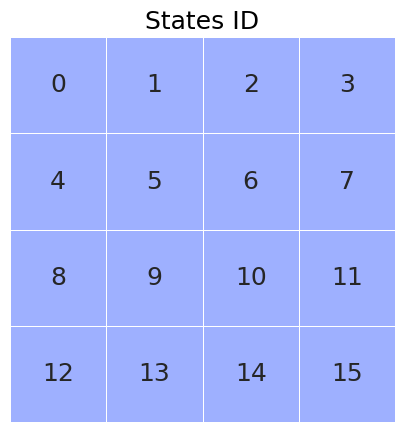

In [13]:
display_state(states, fmt="d", title="States ID", heatmap=False)

The following plot shows the reward obtained in each square of the FrozenLake grid.

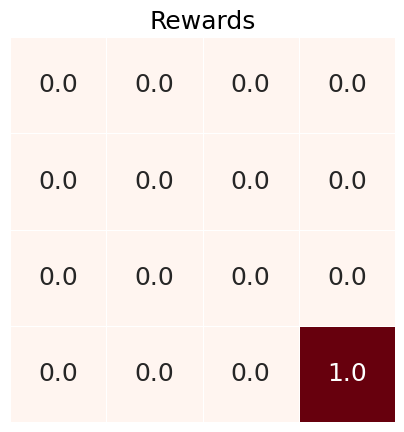

In [14]:
display_state(reward_array, title="Rewards")

The following plot shows whether a square is a final state or not (i.e. whether it ends the simulation or not).

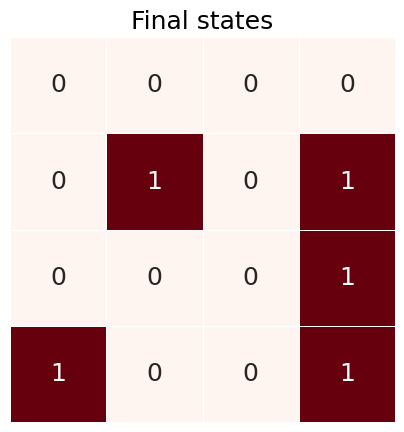

In [15]:
display_state(is_final_array, fmt="d", title="Final states")

The following cells show how to display transitions with the provided `display_transition` function. Figures displayed in squares are the probability to reach these squares from the given (`state`, `action`) pair. Colored squares are the states that may be reached from this pair (a non-zero probability).

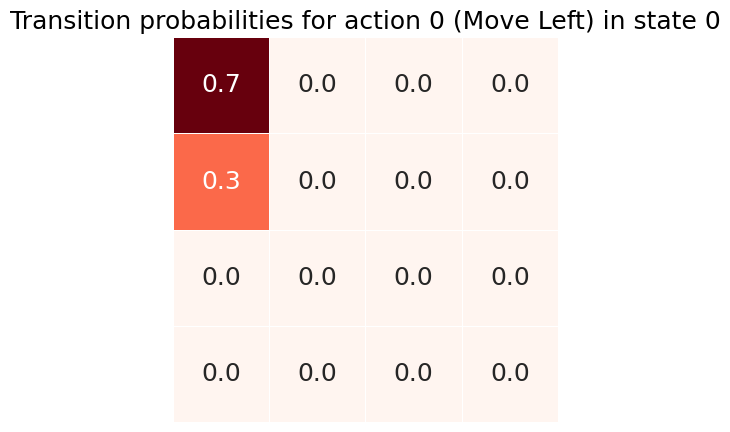

In [30]:
display_transition(state=0, action=0)

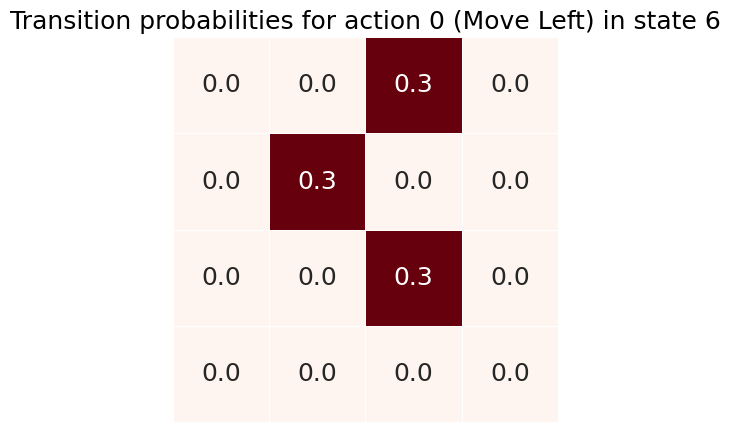

In [31]:
display_transition(state=6, action=0)

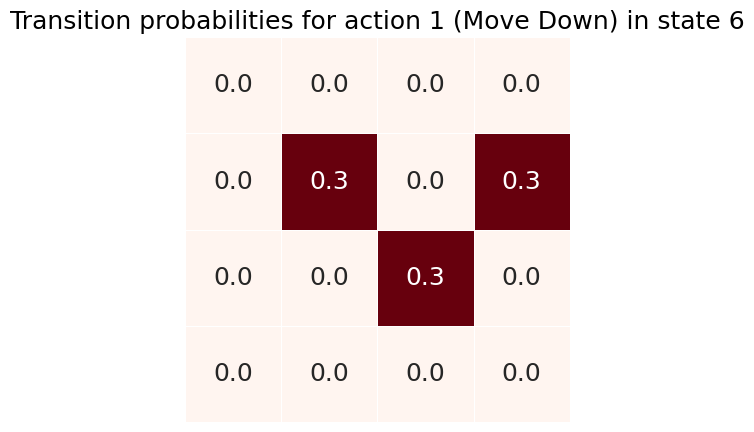

In [32]:
display_transition(state=6, action=1)

### Expected Value

To solve the FrozenLake-v1 problem with Dynamic Programming, we will first use the Value Iteration algorithm described in Algorithm 2.

Notice that the FrozenLake-v1 environment is non-deterministic.
To implement Value Iteration, you will need the transition probability (or the transition function) defined in `transition_array`.
- Use `transition_array[S, A]` to get the probability of reaching each state from state `S` executing action `A`.
- Use `transition_array[S, A, S']` to get the probability of reaching state `S'` from state `S` executing action `A`.

You will also need the previously defined `is_final_array` matrix.
- Use `is_final_array[S]` to know whether `S` is a final state (`True`) or not (`False`).

Finally, you will need the previously defined `reward_array` matrix.
- Use `reward_array[S]` to get the reward obtained by the agent each time it reaches state `S`.

In the following cell, we define `expected_value` and `expected_values` functions for convenience.
The first one returns the expected reward
$$\sum P(\boldsymbol{s}' | \boldsymbol{s}, \boldsymbol{a}) V(\boldsymbol{s}')$$
for a given pair $(\boldsymbol{s}, \boldsymbol{a})$ and a given V-table (value function) $V$.
The second one computes the expected reward for all the actions in $\boldsymbol{s}$.

In [33]:
def expected_value(state: int, action: int, v_array: np.ndarray) -> float:
    """
    Compute the expected value for a given state-action pair.

    Parameters
    ----------
    state : int
        The state from which the action is taken.
    action : int
        The action that is taken.
    v_array : np.ndarray
        The value function represented as a numpy array.
        `v_array` is a 1D numpy array of 16 floats (one value per state).

    Returns
    -------
    float
        The expected value for the given state-action pair.
    """
    # The transition_array is a global variable that contains the transition probabilities for each state-action pair.
    # The expected value for a state-action pair is computed as the sum of the product of the transition probabilities
    # and the values of the states. This is represented by the expression (transition_array[state, action] * v_array).sum().
    return (transition_array[state, action] * v_array).sum()  # compute sum(P(s'|a,s).V(s'))

In [34]:
def expected_values(state: int, v_array: np.ndarray) -> np.ndarray:
    """
    Compute the expected values for all actions from a given state.

    Parameters
    ----------
    state : int
        The state from which the actions are taken.
    v_array : np.ndarray
        The value function represented as a numpy array.
        `v_array` is a 1D numpy array of 16 floats (one value per state).

    Returns
    -------
    np.ndarray
        A numpy array of expected values for all actions from the given state,
        i.e. a 1D numpy array of 4 floats (one value per action).
    """
    # The transition_array is a global variable that contains the transition probabilities for each state-action pair.
    # The expected values for all actions from a given state are computed as the sum of the product of the transition probabilities
    # and the values of the states. This is represented by the expression (transition_array[state] * v_array).sum(axis=1).
    # The axis=1 parameter means that the sum is computed over the second axis (i.e., for each action).
    return (transition_array[state] * v_array).sum(axis=1)   # compute sum(P(s'|a,s).V(s')) for all the actions

### Task 1: Implement the Value Iteration algorithm (compute the *value function* `v_array`)

**Note**: here we use the `display_state` function to show the evolution of the value function `v_array` over iterations.

In [45]:
stop = False

def value_iteration(
    gamma: float = 0.95,
    epsilon: float = 0.001,
    display: bool = False,
) -> Tuple[np.ndarray, List[np.ndarray], List[float]]:
    """
    Perform the value iteration algorithm for a given set of states and actions.

    Parameters
    ----------
    gamma : float, optional
        The discount factor, by default 0.95
    epsilon : float, optional
        The convergence threshold, by default 0.001
    display : bool, optional
        A flag indicating whether to display the value function at each iteration, by default False

    Returns
    -------
    np.ndarray
        The final value function after the value iteration algorithm has converged,
        i.e. a 1D numpy array of 16 floats (one value per state).
    List[np.ndarray]
        The history of the value function at each iteration (a list of 1D numpy arrays of 16 floats).
    List[float]
        The history of the maximum change in the value function at each iteration (the "Bellman residual" delta).
    """
    # Initialize the history of the value function and the maximum change in the value function
    v_array_history: List[np.ndarray] = []
    delta_history: List[float] = []

    # Initialize the value function with zeros
    v_array = np.zeros(len(states))
    stop = False

    # Continue the loop until the value function converges
    while not stop:
        # Display the value function if the display flag is set
        if display:
            display_state(v_array, title=f"Value function (iteration { len(v_array_history) })", cbar=False)
        else:
            print(".", end="")

        # Append the current value function to the history
        v_array_history.append(v_array)

        # Initialize the maximum change in the value function to zero
        delta = 0.0

        # TODO:
        # - Create a deep copy of the current value function to update it
        v_new = np.copy(v_array)

        # - Loop over all states and update the value function
        for state in states:
            q_values = []
            
            # Pour chaque état, on évalue toutes les actions possibles
            for action in actions:
                q_val = 0
                # On somme sur toutes les transitions possibles (probabilité, état suivant, récompense)
                # Note: env.P[state][action] est la structure standard de Gym
                for prob, next_state, reward, _ in env.unwrapped.P[state][action]:
                    q_val += prob * (reward + gamma * v_array[next_state])
                q_values.append(q_val)
            
            # Mise à jour de la valeur : max sur les actions (comportement glouton/greedy)
            best_val = max(q_values)
            
            # Calcul du delta pour la convergence (Norme infinie)
            delta = max(delta, np.abs(best_val - v_array[state]))
            
            # Stockage de la nouvelle valeur
            v_new[state] = best_val
        
        # Mise à jour du tableau principal pour l'itération suivante
        v_array = v_new  

        # Append the maximum change in the value function to the history
        delta_history.append(delta)

        # If the maximum change in the value function is less than the threshold, stop the loop
        if delta < epsilon:
            stop = True

    # Return the final value function, the history of the value function, and the history of the maximum change in the value function
    return v_array, v_array_history, delta_history

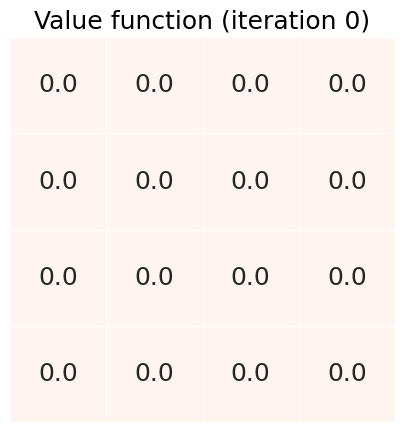

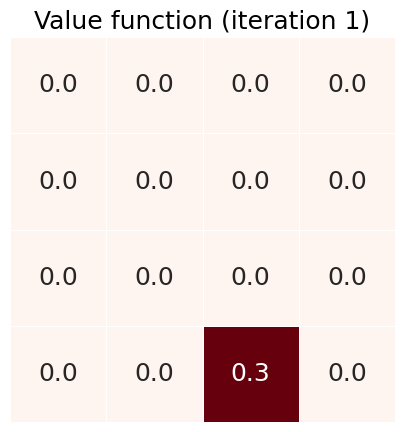

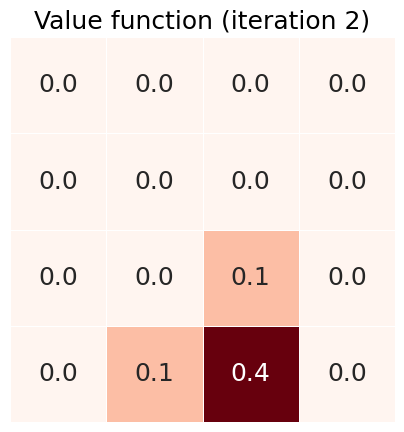

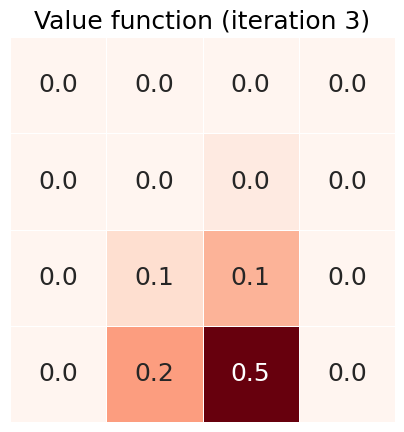

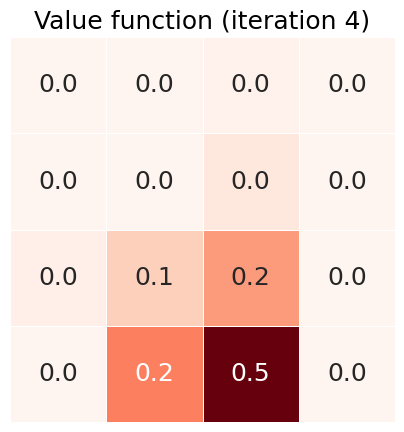

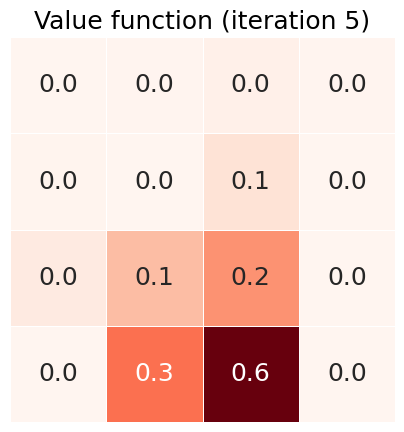

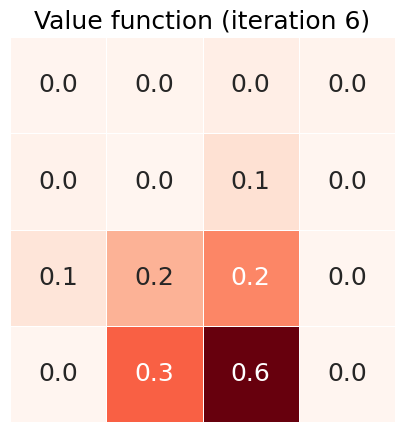

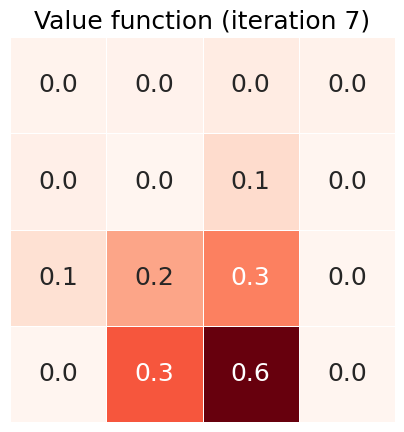

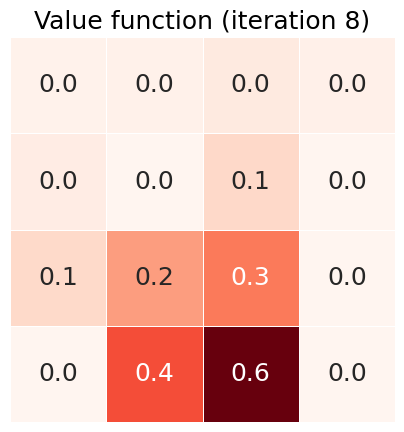

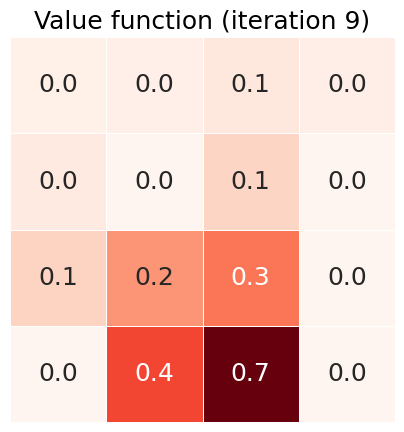

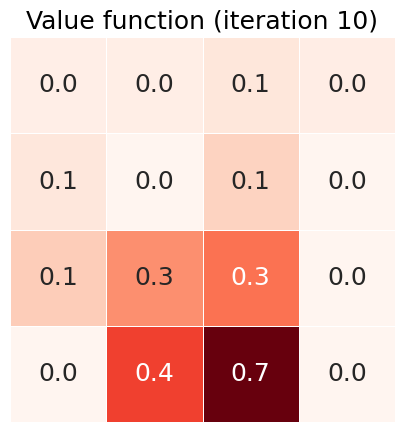

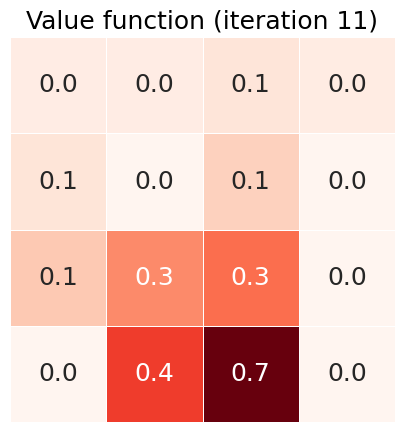

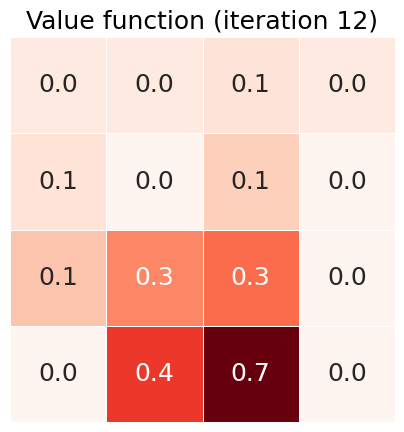

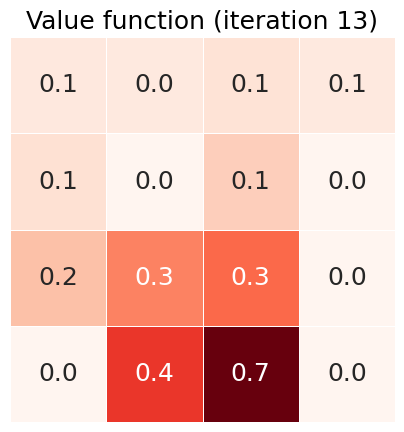

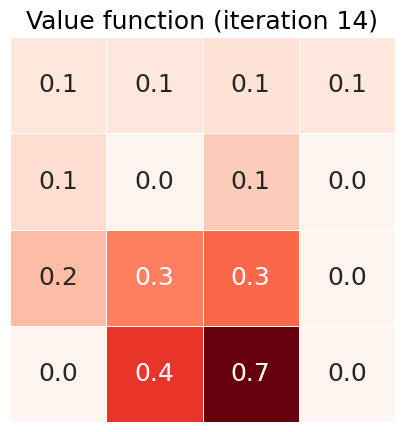

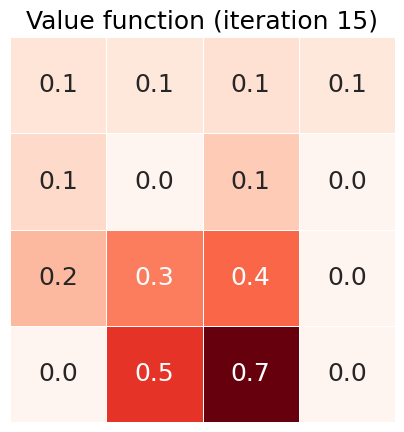

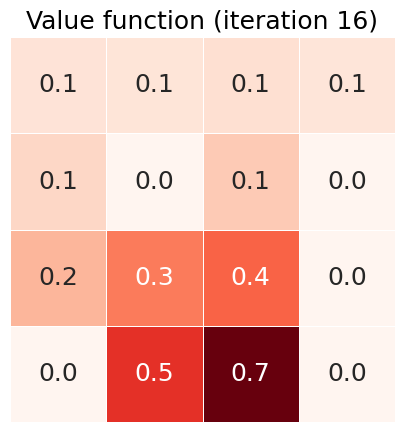

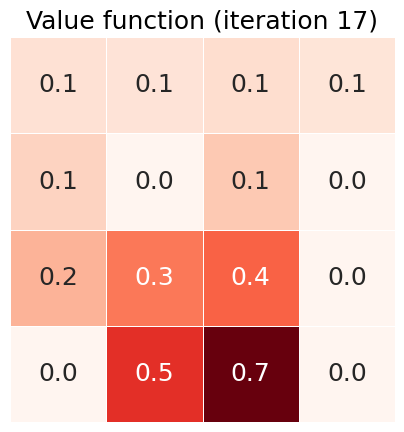

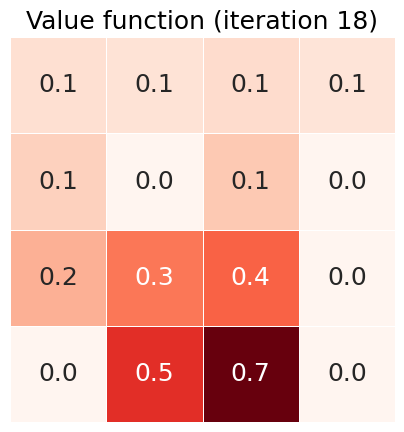

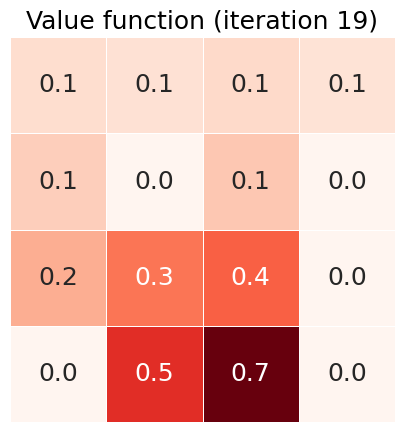

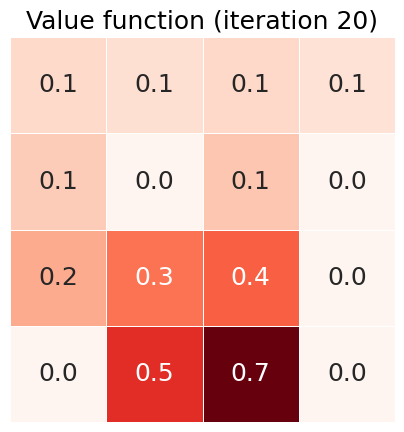

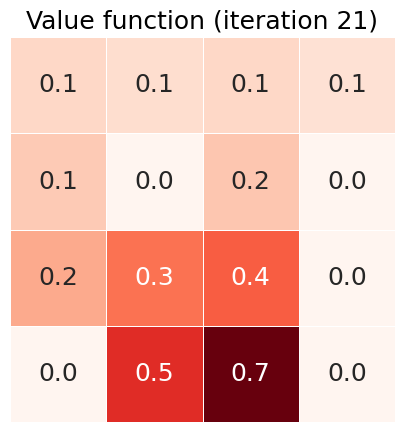

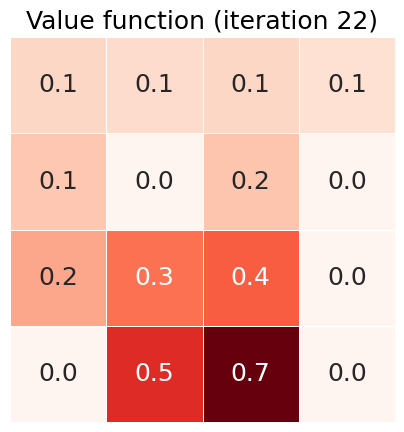

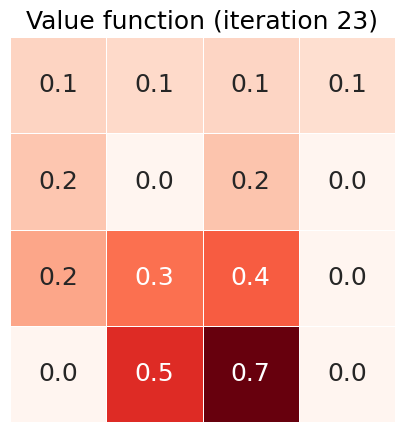

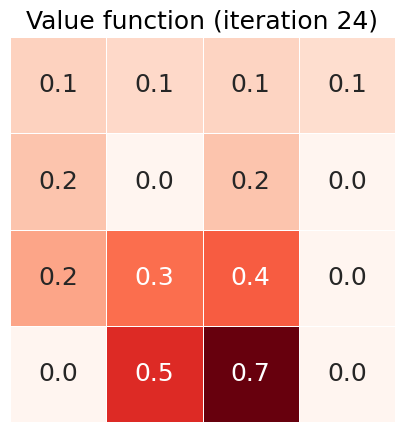

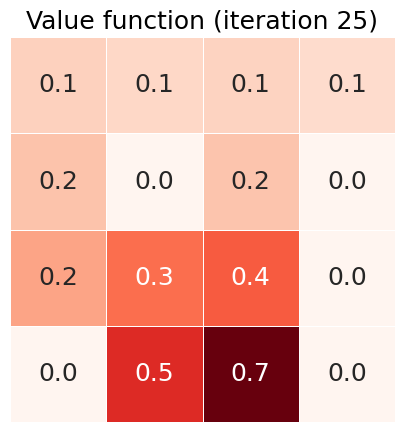

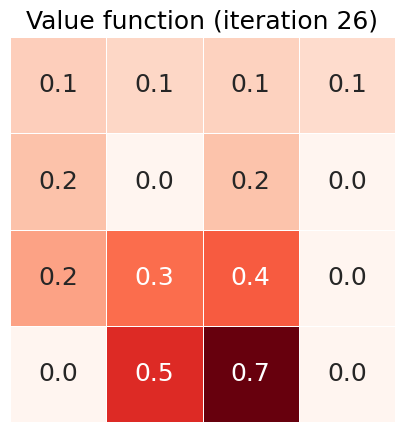

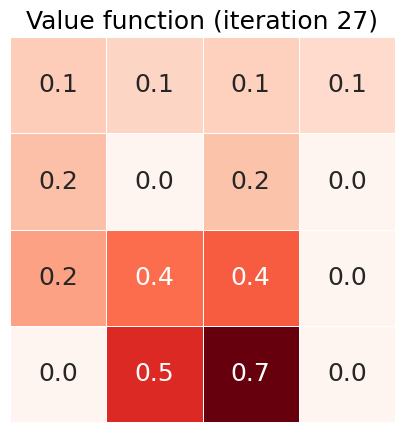

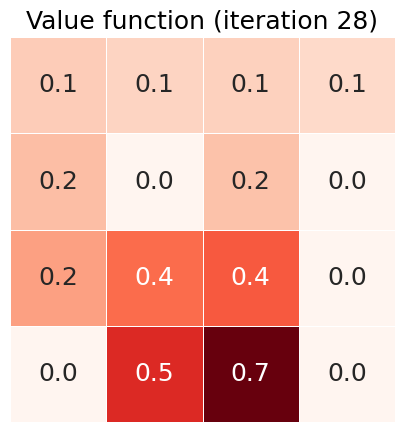

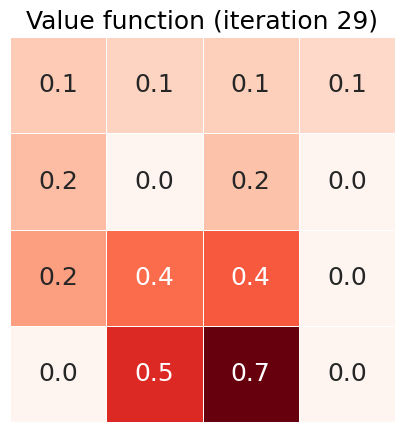

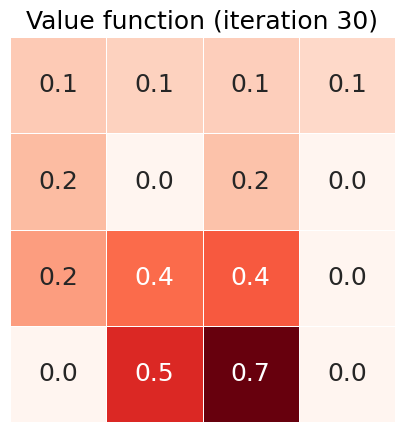

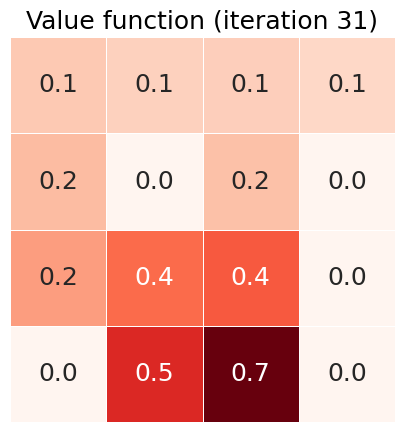

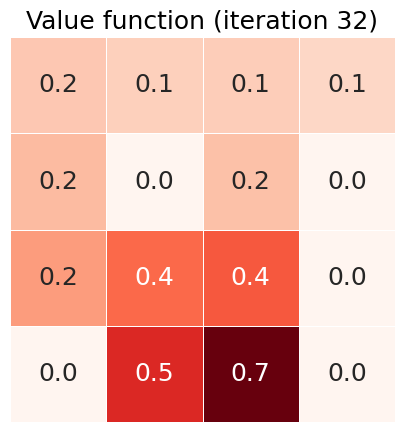

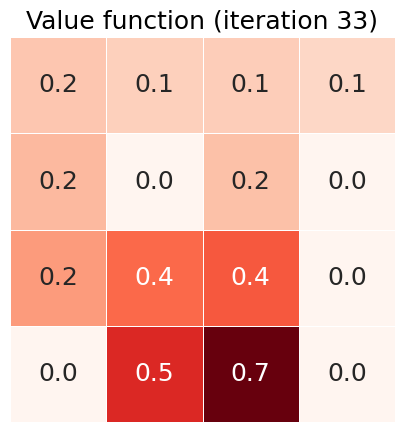

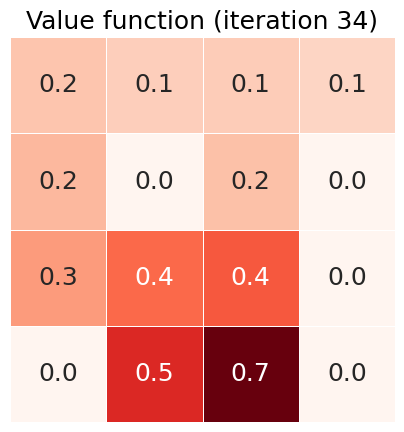

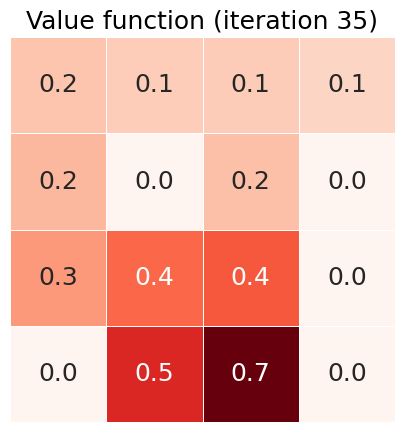

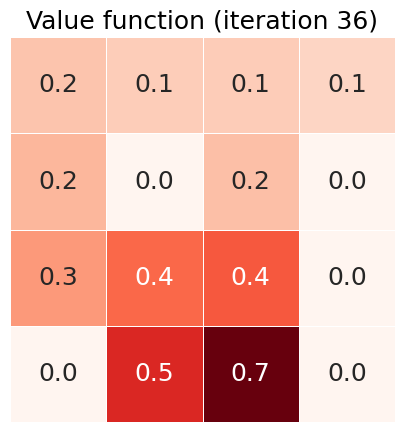

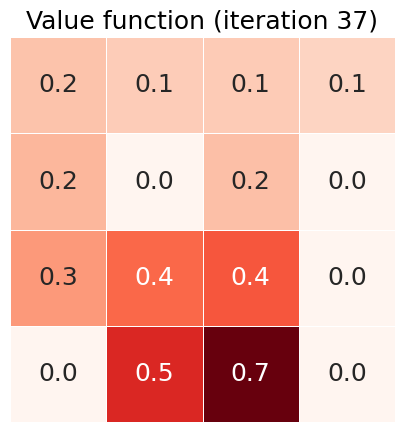

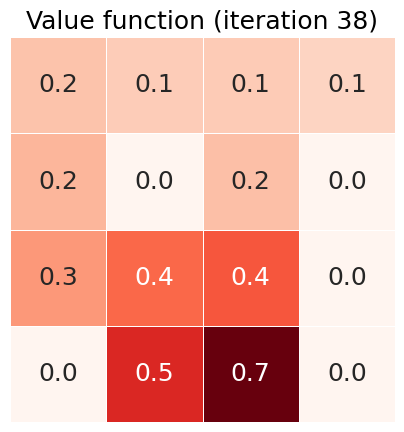

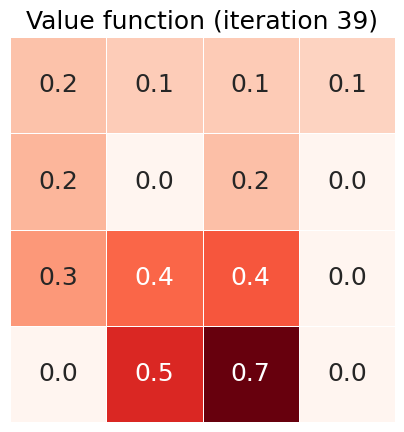

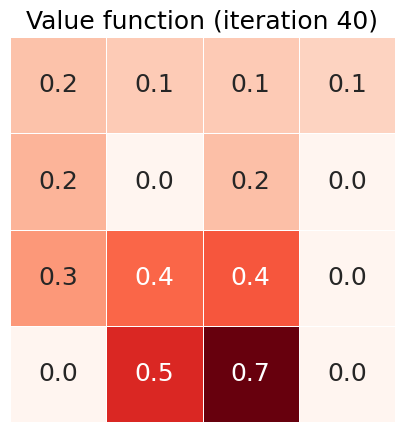

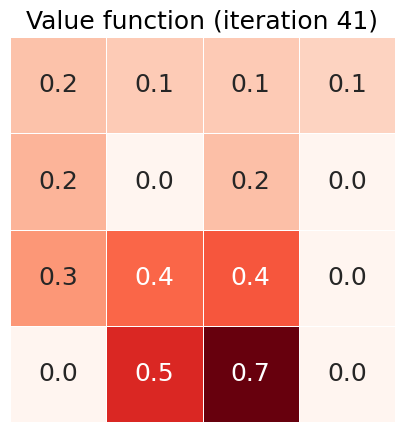

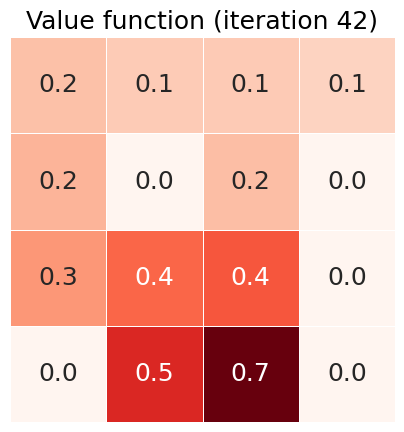

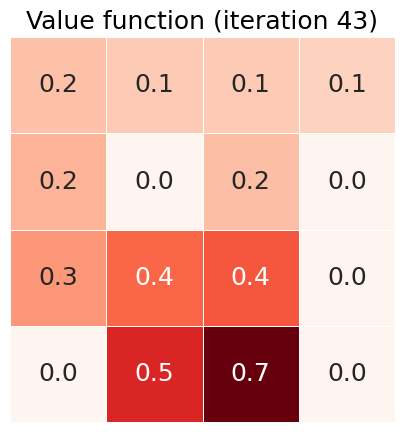

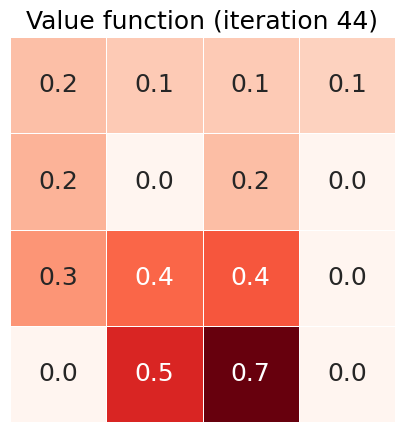

In [46]:
v_array, v_array_history, delta_history = value_iteration(display=True)
display_state(v_array, title=f"Value function (iteration { len(v_array_history) })", cbar=False)

#### Question 1

Copy and paste the output of the following cell into the first question of the *[Lab 3 - Evaluation](https://moodle.ip-paris.fr/mod/quiz/view.php?id=360802)* in Moodle:
*"What is the expected value of the initial state in the FrozenLake environment (using the default discount factor, γ)?"*

In [48]:
e1q1_answer = v_array[0].item()
print(f"{e1q1_answer:.2f}")

0.17


### Display the evolution of the value function over iterations

In [49]:
df_v_hist = pd.DataFrame(v_array_history)
df_v_hist

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0
1,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.333333,0.0
2,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.105556,0.0,0.0,0.105556,0.438889,0.0
3,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.033426,0.0,0.000000,0.066852,0.138981,0.0,0.0,0.172407,0.505741,0.0
4,0.000000,0.000000,0.010585,0.000000,0.000000,0.0,0.044011,0.0,0.021170,0.098606,0.191906,0.0,0.0,0.235917,0.548080,0.0
5,0.000000,0.003352,0.017289,0.003352,0.006704,0.0,0.064122,0.0,0.037929,0.142181,0.218721,0.0,0.0,0.279491,0.581599,0.0
6,0.003184,0.006536,0.026841,0.007598,0.014134,0.0,0.074736,0.0,0.059158,0.169778,0.249502,0.0,0.0,0.317702,0.606012,0.0
7,0.007554,0.011578,0.034572,0.013312,0.024217,0.0,0.087509,0.0,0.076972,0.198348,0.269333,0.0,0.0,0.346273,0.625843,0.0
8,0.013727,0.017006,0.042874,0.019379,0.034435,0.0,0.096237,0.0,0.094854,0.219316,0.288705,0.0,0.0,0.370647,0.641170,0.0
9,0.020637,0.023309,0.050188,0.025850,0.045288,0.0,0.105000,0.0,0.110392,0.238832,0.302962,0.0,0.0,0.389859,0.653742,0.0


Evolution of `v_array` (the estimated value of each state) over iterations (one curve per state):

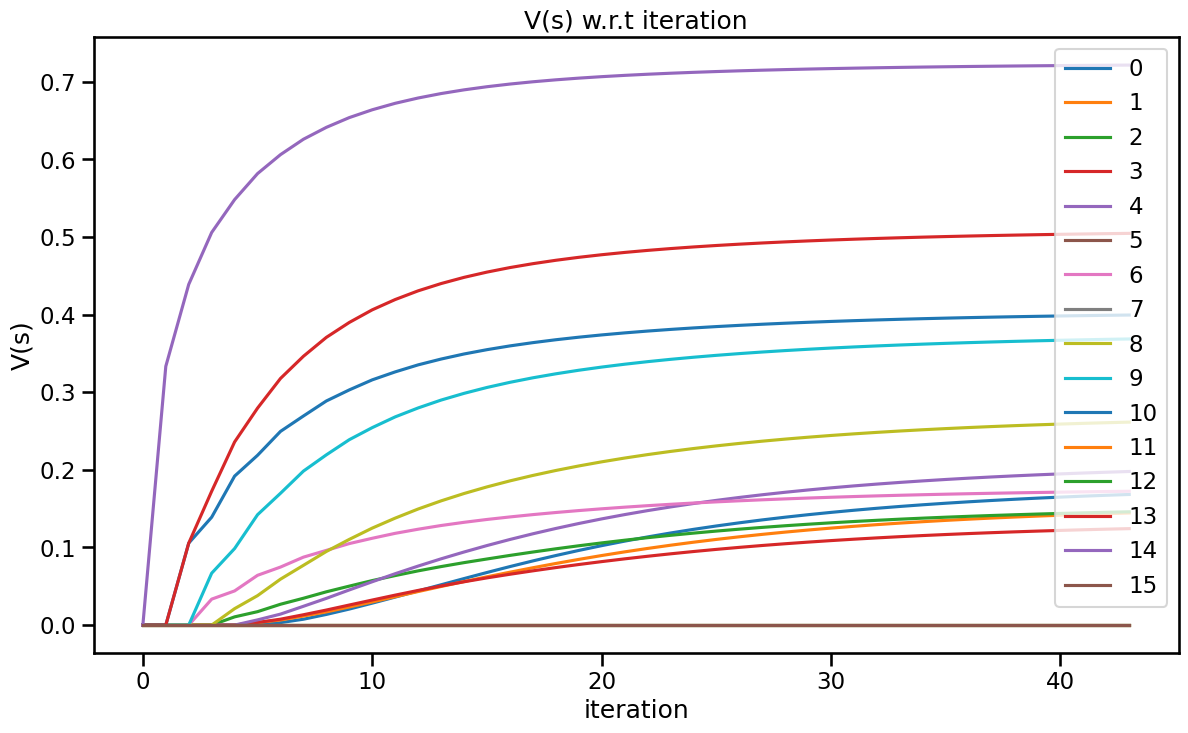

In [50]:
df_v_hist.plot(figsize=(14, 8))
plt.title("V(s) w.r.t iteration")
plt.ylabel("V(s)")
plt.xlabel("iteration")
plt.legend(loc="upper right");

Evolution of `delta` over iterations:

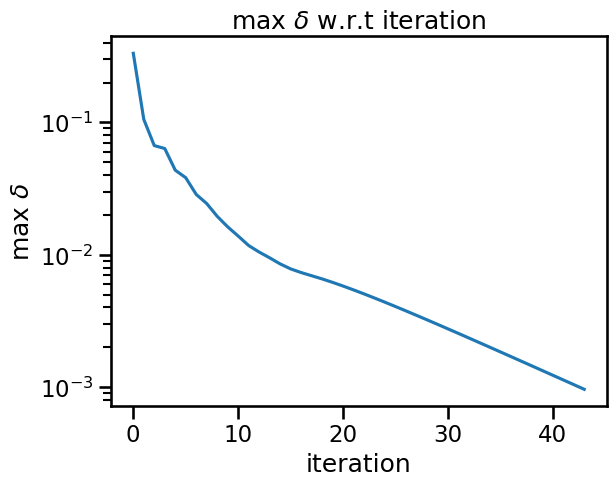

In [51]:
plt.plot(delta_history)
plt.yscale("log")
plt.title(r"$\max~\delta$ w.r.t iteration")
plt.ylabel(r"$\max~\delta$")
plt.xlabel("iteration");

### Task 2: Define the greedy policy (Maximum Expected Utility)

In [59]:
def greedy_policy(state: int, v_array: np.ndarray) -> int:
    """
    Compute the policy that maximizes the expected value for a given state.

    Parameters
    ----------
    state : int
        The state for which the policy is computed.
    v_array : np.ndarray
        The value function represented as a numpy array.
        `v_array` is a 1D numpy array of 16 floats (one value per state).

    Returns
    -------
    int
        The policy that maximizes the expected value for the given state.
    """

    num_actions = env.action_space.n
    q_values = np.zeros(num_actions)
    gamma = 0.95

    # Pour chaque action possible
    for action in range(num_actions):
        # Calcul de l'espérance de la valeur future (Bellman expectation equation)
        for prob, next_state, reward, _ in env.unwrapped.P[state][action]:
            # Q(s,a) += Proba * (Reward_immédiat + gamma * Valeur_état_suivant)
            q_values[action] += prob * (reward + gamma * v_array[next_state])

    # On choisit l'action qui a la plus grande Q-value (argmax)
    policy = int(np.argmax(q_values))

    return policy

Applying the `greedy_policy` on each state gives us the policy matrix:

In [60]:
policy = [greedy_policy(state, v_array) for state in states]

#### Question 2

Copy and paste the output of the following cell into the second question of the *[Lab 3 - Evaluation](https://moodle.ip-paris.fr/mod/quiz/view.php?id=360802)* in Moodle:  
*"What is the optimal action for the 9th state in the FrozenLake environment (using the default discount factor, γ)?"*

In [63]:
e1q2_answer = policy[8]
print(e1q2_answer)

3


### Display the optimized policy

The following cell gives us a graphical representation of the optimal policy we have computed. The figure in each square is the optimal action to execute in the corresponding state (0 = "move left", 1 = "move down", 2 = "move right", 3 = "move up").

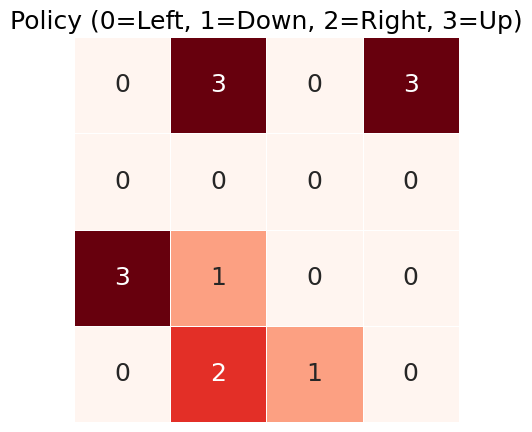

In [65]:
display_policy(policy)

### Evaluate Value Iteration with Gymnasium (single trial)

So far, we have computed the value function `v_array` for one *episode*.
The environment is stochastic, thus if we apply the computed policy several times on the environment, we may have different results.
To measure the performance of our value function `v_array`, we should assess it several times and count the number of successful trials.
Gymnasium considers an agent to successfully solve the FrozenLake problem if it reaches 76% success rate over the last 100 trials (or "episodes").

In [66]:
env._max_episode_steps = 1000

In [67]:
vi_reward_list: List[float] = []

NUM_EPISODES = 1000

for episode_index in range(NUM_EPISODES):
    state, info = env.reset()
    done = False
    # t = 0

    while not done:
        action = greedy_policy(state, v_array)
        state, reward, done, truncated, info = env.step(action)
        # t += 1

    vi_reward_list.append(float(reward))
    # print("Episode finished after {} timesteps ; reward = {}".format(t, reward))

print(sum(vi_reward_list) / NUM_EPISODES)

env.close()

0.77


### Bonus question: What do you think the discount factor $\gamma$ is for?

The discount factor $\gamma \in [0, 1)$ serves three critical purposes in Reinforcement Learning:

1.  **Mathematical Convergence:**
    It ensures that the sum of rewards (the Return $G_t$) remains finite in infinite-horizon settings. By weighting future rewards by $\gamma^t$, the return becomes a convergent geometric series (assuming bounded rewards):
    $$G_t = \sum_{k=0}^{\infty} \gamma^k r_{t+k+1}$$

2.  **Time Preference & Horizon:**
    It controls the agent's foresight.
    * **$\gamma \to 0$ (Myopic):** The agent cares only about immediate rewards.
    * **$\gamma \to 1$ (Far-sighted):** The agent values long-term rewards almost as much as immediate ones.
    
    Effectively, $\gamma$ defines the "horizon" of the problem. A value of $\gamma$ effectively creates a horizon of length $\approx \frac{1}{1-\gamma}$ steps.

3.  **Incentive for Speed:**
    In stochastic shortest path problems (like *FrozenLake* or *Navigation*), where the reward is 0 until the goal is reached (or -1 per step), a $\gamma < 1$ incentivizes the agent to reach the goal as quickly as possible to maximize the discounted value $(1-\gamma)\gamma^d$, where $d$ is the number of steps.

The discount rate determines the present value of future rewards.
If $\gamma = 0$, the agent is "myopic" in being concerned only with maximizing the immediate rewards.
As $\gamma$ approaches 1, the return objective takes future rewards into account more strongly.

### Evaluate Value Iteration for different value of $\gamma$ with confidence interval (bootstrap)

In [74]:
# %%time

NUM_EPISODES = 1000

vi_gamma_reward_list: List[Dict[str, float]] = []

for gamma in (0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.85, 0.9, 0.95, 0.99):
    v_array, v_array_history, delta_history = value_iteration(gamma=gamma)

    for episode_index in range(NUM_EPISODES):
        state, info = env.reset()
        done = False

        while not done:
            action = greedy_policy(state, v_array)
            state, reward, done, truncated, info = env.step(action)

        vi_gamma_reward_list.append({"gamma": gamma, "reward": float(reward)})

env.close()

..........................................................................................................................................................................................................................................................

In [75]:
df = pd.DataFrame(vi_gamma_reward_list)
df.tail()

,gamma,reward
10995,0.99,0.0
10996,0.99,1.0
10997,0.99,1.0
10998,0.99,1.0
10999,0.99,1.0


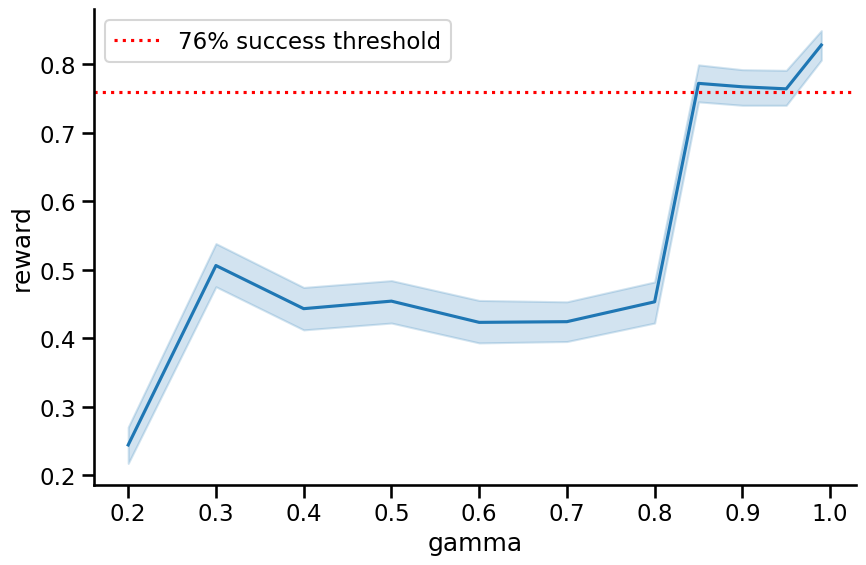

In [76]:
# Plot mean reward (with its 95% confidence interval)

sns.relplot(x="gamma", y="reward", kind="line", data=df, height=6, aspect=1.5)
plt.axhline(0.76, color="red", linestyle=":", label="76% success threshold");   # 76% success threshold
plt.legend();

### Display the Value Iteration optimal policy with respect to $\gamma$


========== GAMMA =  0.2 ==========

....



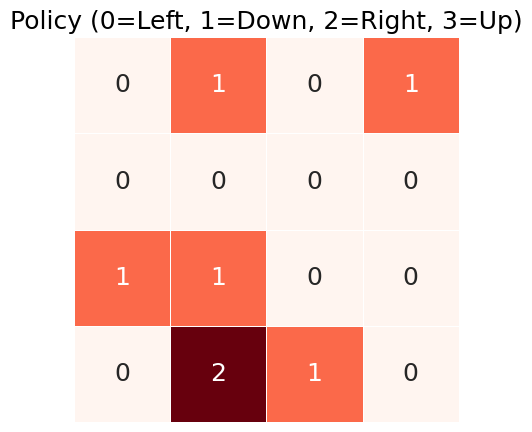


========== GAMMA =  0.3 ==========

.....



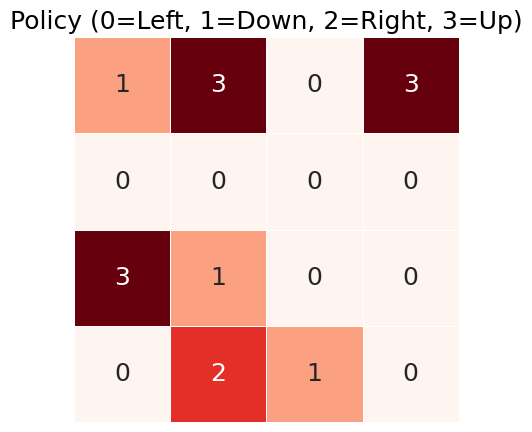


========== GAMMA =  0.4 ==========

......



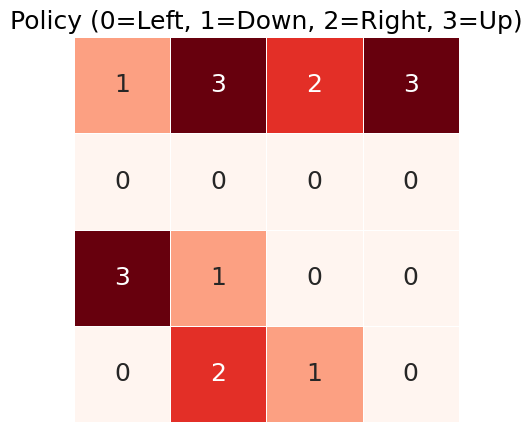


========== GAMMA =  0.5 ==========

.......



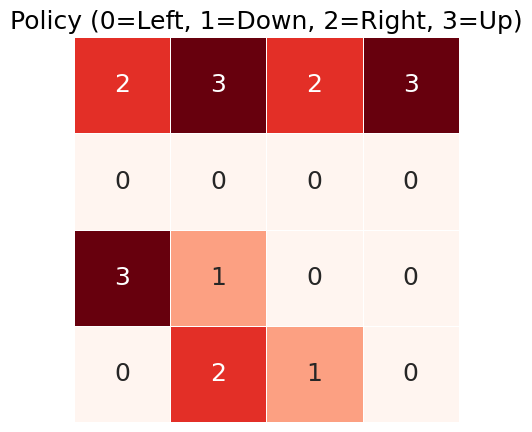


========== GAMMA =  0.6 ==========

........



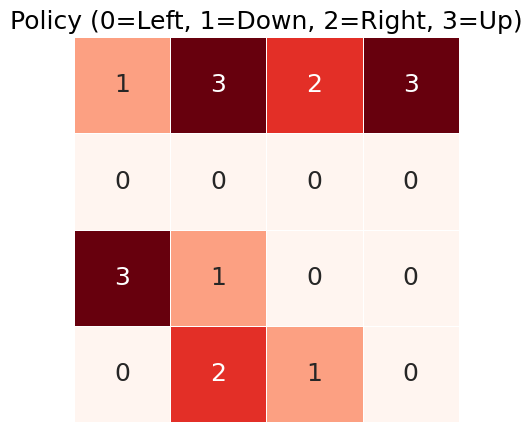


========== GAMMA =  0.7 ==========

...........



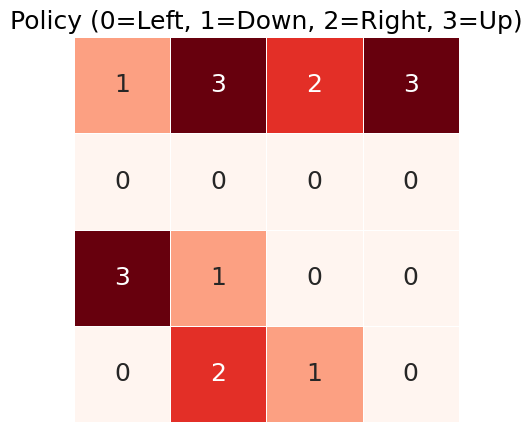


========== GAMMA =  0.8 ==========

...............



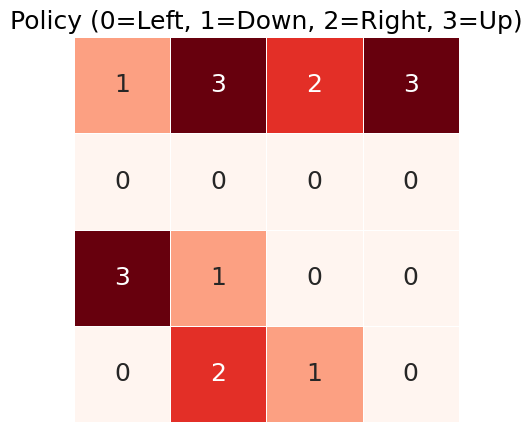


========== GAMMA =  0.85 ==========

..................



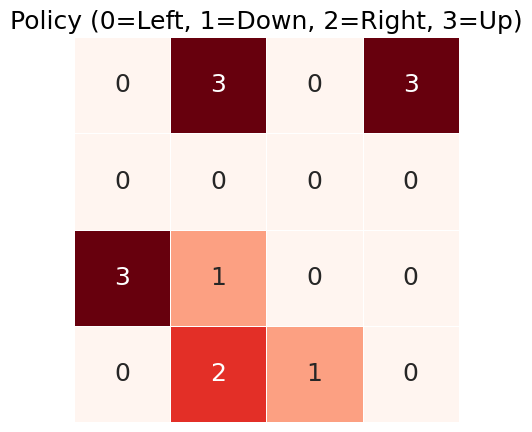


========== GAMMA =  0.9 ==========

...........................



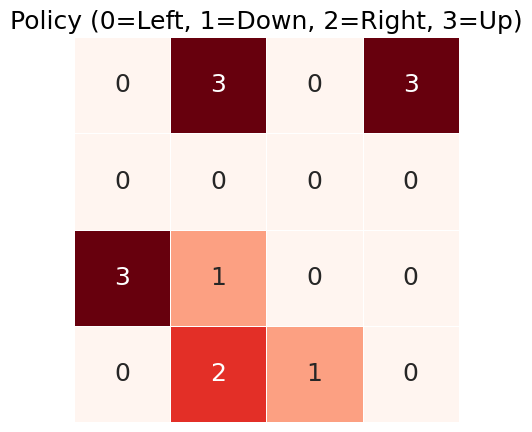


========== GAMMA =  0.95 ==========

............................................



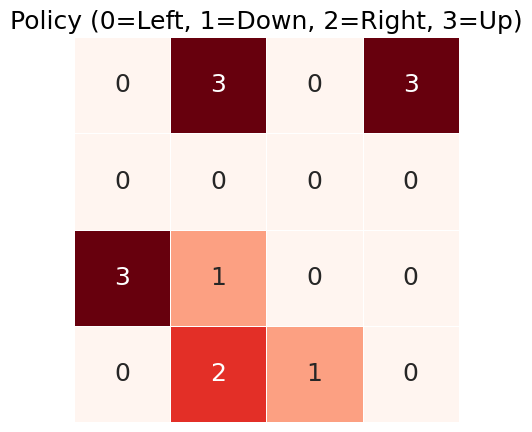


========== GAMMA =  0.99 ==========

.........................................................................................................



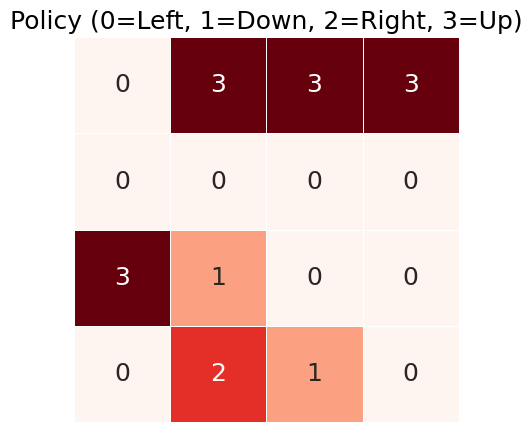

In [77]:
for gamma in (0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.85, 0.9, 0.95, 0.99):
    print()
    print("=" * 10, "GAMMA = ", gamma, "=" * 10)
    print()

    v_array, v_array_history, delta_history = value_iteration(gamma=gamma)

    print()
    print()

    policy = [greedy_policy(state, v_array) for state in states]
    display_policy(policy)

## Exercise 2: Implement the Policy Iteration algorithm

*Policy Iteration* **[HOWARD60]** is another popular Dynamic Programming algorithm to
compute MDP's optimal policy. In practice, it is often faster than Value Iteration.

The Policy Iteration algorithm alternates the following two steps, starting with an initial policy $\pi_0$:
1. **Policy Evaluation**: given a policy $\pi_i$, compute $V^{\pi_i}(\boldsymbol{s}) ~ \forall \boldsymbol{s} \in \mathcal{S}$, the expected value of each state when $\pi_i$ is followed.
2. **Policy Improvement**: compute a new policy $\pi_{i+1}$, using one-step look-ahead based on $V^{\pi_i}$ and using the principle of *Maximum Expected Utility* as follows
$$
\pi_{i+1}(\boldsymbol{s}) = \arg \max_{\boldsymbol{a} \in \mathcal{A}} \sum_{\boldsymbol{s}'  \in \mathcal{S}} P(\boldsymbol{s}'|\boldsymbol{s},\boldsymbol{a}) \left( r(\boldsymbol{s},\boldsymbol{a},\boldsymbol{s}') + \gamma V^{\pi_{i}}(\boldsymbol{s}') \right)
$$

In the following exercise we will assume that the reward only depends on the state: $r(\boldsymbol{s}) \equiv \mathcal{R}(\boldsymbol{s}, \boldsymbol{a}, \boldsymbol{s}')$.
Thus the *Policy Improvement* can be rewritten as follow:

$$
\pi_{i+1}(\boldsymbol{s}) = \arg\max_{\boldsymbol{a} \in \mathcal{A}} \sum_{\boldsymbol{s}' \in \mathcal{S}} P(\boldsymbol{s}' | \boldsymbol{s}, \boldsymbol{a}) V^{\pi_i}(\boldsymbol{s}')
$$

($r$ and $\gamma$ can disappear as they have no influence on the $\arg\max_{\boldsymbol{a}}$ result).

Algorithm 3 describes the two-step procedure.
The algorithm terminates when the *Policy Improvement* step yields no change in the utilities.

___
### Algorithm 3: Policy Iteration

**Input**:<br>
$\quad$ $MDP = \langle \mathcal{S}, \mathcal{A}, P, r \rangle$, a Markov Decision Process<br>
**Local variables**: <br>
$\quad$ $V$, vector of utilities for states in $\mathcal{S}$, initially zero <br>
$\quad$ $\pi$, a policy vector indexed by state, initially random <br>
<br>
**repeat** <br>
$\quad$ $V \leftarrow \text{POLICY-EVALUATION}(\pi, V, \text{MDP})$ <br>
$\quad$ unchanged $\leftarrow$ true <br>
$\quad$ **for all** state $\boldsymbol{s} \in \mathcal{S}$ **do** <br>
$\quad\quad$ **if** $\displaystyle \max_{\boldsymbol{a} \in \mathcal{A}} \left[ \sum_{\boldsymbol{s}' \in \mathcal{S}} P(\boldsymbol{s}'|\boldsymbol{s},\boldsymbol{a}) V[\boldsymbol{s}'] \right] > \sum_{\boldsymbol{s}' \in \mathcal{S}} P(\boldsymbol{s}' | \boldsymbol{s}, \pi_{i}(\boldsymbol{s})) V[\boldsymbol{s}']$ **then** <br>
$\quad\quad\quad$ $\displaystyle \pi[\boldsymbol{s}] \leftarrow \arg\max_{\boldsymbol{a} \in \mathcal{A}} \left[ \sum_{\boldsymbol{s}' \in \mathcal{S}} P(\boldsymbol{s}'|\boldsymbol{s},\boldsymbol{a}) V[\boldsymbol{s}'] \right]$ <br>
$\quad\quad\quad$ unchanged $\leftarrow$ false <br>
$\quad\quad$ **end if** <br>
$\quad$ **end for** <br>
**until** unchanged <br>
<br>
**return** $\pi$
___

Solving the POLICY-EVALUATION routine is much simpler than solving the standard
Bellman equations (which is what Value Iteration does).  Indeed, the action in each
state is fixed by the policy, thus the "max" operator disappears and Bellman
equations become linear.
As a result, $V^{\pi_i}$ can be computed by solving the linear system of these
*simplified Bellman equations* (Eq. 5) for
each state.

\begin{equation}
    V^{\pi_i}(\boldsymbol{s}) = \left\{
    \begin{array}{l l}
        r(\boldsymbol{s})               & \quad \text{if $\boldsymbol{s}$ is a final state} \\
        \displaystyle r(\boldsymbol{s}) + \gamma \sum_{\boldsymbol{s}' \in \mathcal{S}} P(\boldsymbol{s}' | \boldsymbol{s}, \pi_{i}(\boldsymbol{s})) ~ V^{\pi_{i}}(\boldsymbol{s}')     & \quad \text{otherwise}\\
    \end{array} \right.
    \tag{5}
\end{equation}

### Convergence

As the number of states and policies is finite, and as the policy is improved
at each iteration, Policy Iteration converges in a finite number of iterations (often
small in practice).
However, within each iteration, solving the
POLICY-EVALUATION routine may cost a lot (its complexity is $O(|\mathcal{S}|^3)$).

### Task 1: Define the (exact) Policy Evaluation function

**Tips:** use `numpy.linalg.inv` or `numpy.linalg.solve` to solve the linear system of equations defined by Eq. 5.

In [87]:
def policy_evaluation(policy: np.ndarray, gamma: float) -> np.ndarray:
    """
    Evaluate a policy by solving a system of linear equations.

    Parameters
    ----------
    policy : np.ndarray
        The policy to evaluate, represented as a numpy array.
        `policy` is a 1D numpy array of 16 integers (one action per state).
    gamma : float
        The discount factor.

    Returns
    -------
    np.ndarray
        The value function for the given policy,
        i.e. a 1D numpy array of 16 floats (one value per state).
    """

    # Implement the policy evaluation algorithm here by solving the system of linear equations defined by Eq. 5.
    num_states = env.observation_space.n  # Généralement 16 pour FrozenLake
    
    # 1. Initialisation du système linéaire Ax = b
    # A sera (I - gamma * P_pi)
    # b sera le vecteur des récompenses espérées R_pi
    a_mat = np.eye(num_states)
    b_vec = np.zeros(num_states)

    # 2. Construction de la matrice A et du vecteur b
    for state in range(num_states):
        action = policy[state]
        
        # Pour chaque transition possible à partir de (state, action)
        for prob, next_state, reward, done in env.unwrapped.P[state][action]:
            # Contribution à R_pi (partie droite de l'équation)
            b_vec[state] += prob * reward
            
            # Contribution à P_pi (partie gauche de l'équation)
            # L'équation est : V(s) - gamma * sum(P(s'|s,a) * V(s')) = R(s,a)
            # Si l'état suivant est terminal (done), le terme V(s') vaut 0 par définition
            if not done:
                a_mat[state, next_state] -= gamma * prob

    # 3. Résolution du système linéaire
    x = np.linalg.solve(a_mat, b_vec)

    # Return the solution x, which represents the value function for the given policy
    return x

### Task 2: Define the Policy Improvement function

In [88]:
def policy_iteration(
    gamma: float,
    initial_policy: Optional[np.ndarray] = None,
    policy_evaluation_function: Callable[[np.ndarray, float], np.ndarray] = policy_evaluation,
    verbose: bool = False
) -> np.ndarray:
    """
    Perform the policy iteration algorithm for a given set of states and actions.

    Parameters
    ----------
    gamma : float
        The discount factor.
    initial_policy : np.ndarray, optional
        The initial policy, by default None. If None, a random initial policy is used.
        If provided, `initial_policy` is a 1D numpy array of 16 integers (one action per state).
    policy_evaluation_function : Callable[[np.ndarray, float], np.ndarray], optional
        The function to use for policy evaluation, by default `policy_evaluation`.
    verbose : bool, optional
        If True, print the policy at each iteration, by default False.

    Returns
    -------
    np.ndarray
        The optimal policy after the policy iteration algorithm has converged,
        i.e. a 1D numpy array of 16 integers (one action per state).
    """

    # 1. Initialisation
    num_states = env.observation_space.n
    
    if initial_policy is None:
        # Politique aléatoire si aucune n'est fournie
        policy = np.random.randint(0, env.action_space.n, size=num_states)
    else:
        policy = np.array(initial_policy, copy=True)

    policy_stable = False
    iterations = 0

    # Boucle jusqu'à stabilité
    while not policy_stable:
        if verbose:
            print(f"Iteration {iterations}...")

        # 2. Policy Evaluation
        # On calcule V_pi pour la politique actuelle
        v_values = policy_evaluation_function(policy, gamma)

        # 3. Policy Improvement
        policy_stable = True
        
        for state in range(num_states):
            old_action = policy[state]
            
            # On choisit la meilleure action selon V_pi (étape gloutonne)
            # Note: greedy_policy utilise l'équation d'optimalité Q(s,a)
            new_action = greedy_policy(state, v_values)
            
            # Mise à jour de la politique
            policy[state] = new_action
            
            # Si l'action change pour au moins un état, la politique n'est pas encore stable
            if old_action != new_action:
                policy_stable = False
        
        iterations += 1

    # Return the final policy after the policy iteration algorithm has converged
    return policy

### Compute the FrozenLake optimal policy for a given discount factor $\gamma$

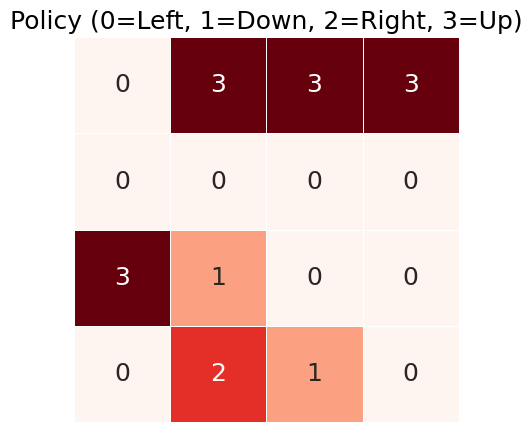

In [89]:
gamma = 0.99

policy = policy_iteration(gamma=gamma, policy_evaluation_function=policy_evaluation)

display_policy(policy)

### Evaluate Policy Iteration with Gymnasium

In [90]:
env._max_episode_steps = 1000

In [91]:
pi_reward_list: List[float] = []

NUM_EPISODES = 10000

for episode_index in range(NUM_EPISODES):
    state, info = env.reset()
    done = False
    # t = 0

    while not done:
        action = policy[state]
        state, reward, done, truncated, info = env.step(action)
        # t += 1

    pi_reward_list.append(float(reward))
    # print("Episode finished after {} timesteps ; reward = {}".format(t, reward))

e2q3_answer = sum(pi_reward_list) / NUM_EPISODES
print(e2q3_answer)

env.close()

0.8253


### Question 3

Copy and paste the output of the following cell into the first question of the *[Lab 3 - Evaluation](https://moodle.ip-paris.fr/mod/quiz/view.php?id=360802)* in Moodle:  
*"What is the success rate of Policy Iteration on the FrozenLake environment (using the default discount factor, γ)?"*

In [92]:
print(f"{e2q3_answer:.2f}")

0.83


### Evaluate Policy Iteration for different $\gamma$ with confidence interval (bootstrap)

In [93]:
%%time

NUM_EPISODES = 1000

pi_gamma_reward_list: List[Dict[str, float]] = []

for gamma in (0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.85, 0.9, 0.99):
    print("gamma:", gamma)
    policy = policy_iteration(gamma=gamma)

    for episode_index in range(NUM_EPISODES):
        state, info = env.reset()
        done = False

        while not done:
            action = policy[state]
            state, reward, done, truncated, info = env.step(action)

        pi_gamma_reward_list.append({"gamma": gamma, "reward": float(reward)})

env.close()

gamma: 0.2
gamma: 0.3
gamma: 0.4
gamma: 0.5
gamma: 0.6
gamma: 0.7
gamma: 0.8
gamma: 0.85
gamma: 0.9
gamma: 0.99
CPU times: total: 1.56 s
Wall time: 1.55 s


In [94]:
df = pd.DataFrame(pi_gamma_reward_list)
df.tail()

,gamma,reward
9995,0.99,1.0
9996,0.99,0.0
9997,0.99,1.0
9998,0.99,1.0
9999,0.99,1.0


### Plot mean reward (with its 95% confidence interval)

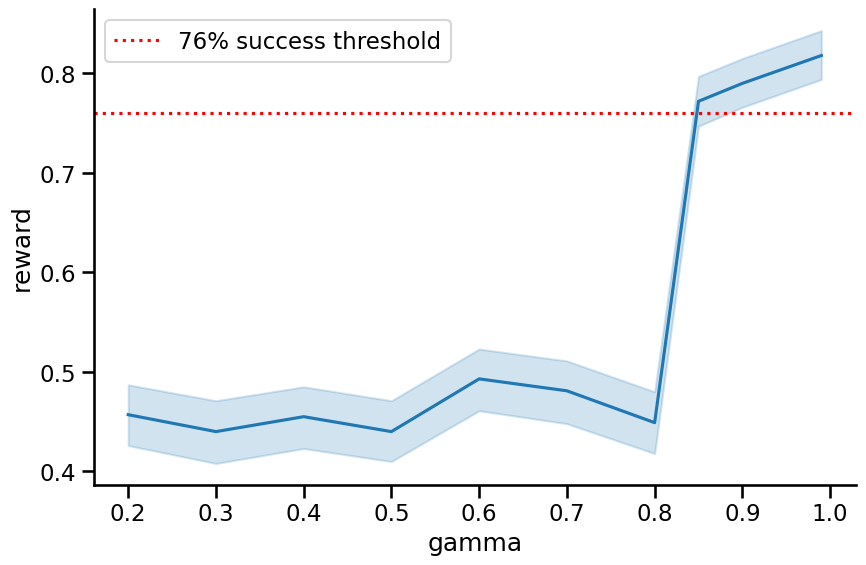

In [95]:
sns.relplot(x="gamma", y="reward", kind="line", data=df, height=6, aspect=1.5)
plt.axhline(0.76, color="red", linestyle=":", label="76% success threshold");   # 76% success threshold
plt.legend();

## References

**[BELLMAN57]** Richard Ernest Bellman. *Dynamic Programming*. Princeton University Press, Princeton,
New Jersey, USA, 1957. [[2010 reissue]](https://press.princeton.edu/books/paperback/9780691146683/dynamic-programming?_gl=1*1vmwsa4*_up*MQ..*_ga*OTYzMTUzOTU0LjE3MzgwMDI1NjY.*_ga_N1W9JWKLY3*MTczODAwMjU1OC4xLjEuMTczODAwMjY5NS4wLjAuNzE0NjQxNTkx) [[Nearby libraries]](https://focus.universite-paris-saclay.fr/primo-explore/search?query=any,contains,9780691146683&tab=default_tab&search_scope=default_scope&vid=33PUP_VU1&lang=en_US&offset=0)

**[HOWARD60]** R.A. Howard. *Dynamic Programming and Markov Processes*. MIT Press, Cambridge,
Massachusetts, 1960.

**[SUTTON18]** Sutton and Barto. [*Reinforcement Learning - An Introduction*](http://incompleteideas.net/book/RLbook2020.pdf). MIT Press, 2018 (second edition). Chapter 4.

**[BERTSEKAS05]** Dimitri Bertsekas. *Dynamic programming and optimal control. Volume I*. Athena Scientific, 2005. [[Nearby libraries]](https://focus.universite-paris-saclay.fr/primo-explore/fulldisplay?docid=33IMT_ILS22676&context=L&vid=33PUP_VU1&lang=en_US&search_scope=default_scope&adaptor=Local%20Search%20Engine&isFrbr=true&tab=default_tab&query=any,contains,bertsekas&sortby=date&facet=frbrgroupid,include,12227458&offset=0)

**[BERTSEKAS12]** Dimitri Bertsekas. *Dynamic programming and optimal control : Approximate Dynamic Programming. Volume II*. Athena Scientific, 2012. [[Nearby libraries]](https://focus.universite-paris-saclay.fr/primo-explore/fulldisplay?docid=33ENSTA_ILS000044105&context=L&vid=33PUP_VU1&lang=en_US&search_scope=default_scope&adaptor=Local%20Search%20Engine&isFrbr=true&tab=default_tab&query=any,contains,bertsekas&offset=0)

## Going further

In this lab we have introduced Reinforcement Learning in a very specific case where the *agent* (the algorithm) has a perfect knowledge of the environment (transition and reward functions).

This is convenient to introduce basic concepts but we cannot expect this assumption to be true in many practical problems.
A lot of sophisticated algorithms have been developed recently and most of them have been implemented in [Stable Baselines 3](https://stable-baselines3.readthedocs.io/en/master/) library and can be used in [Gymnasium](https://gymnasium.farama.org/) benchmark library.

Also, for those who want to go further, one of the best books in reinforcement learning is freely available on the web: http://incompleteideas.net/book/RLbook2018.pdf